# Level 3 · Task 3 — Neural Networks with TensorFlow/Keras
### Codveda Technologies — Machine Learning Internship
**Intern:** Mouhamed Diop · **ID:** CV/A1/79278

---
**Goal:** Build a feed-forward neural network to classify handwritten digits.
**Steps:** load & preprocess → design architecture → train (backpropagation) → evaluate
(accuracy) → visualize training/validation loss.
**Dataset:** `load_digits` (1,797 × 8×8 images, 10 classes) — offline, no download needed.
**Tools:** Python, TensorFlow/Keras, scikit-learn, matplotlib.

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

tf.random.set_seed(42); np.random.seed(42)
print("TensorFlow", tf.__version__)

I0000 00:00:1784892333.624990       8 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.21.0


## Step 1 — Load & Preprocess
Each image is an 8×8 grid → flattened to 64 features. We scale pixel values and one-hot the
labels (10 classes).

Data shape: (1797, 64) | Classes: [0 1 2 3 4 5 6 7 8 9]


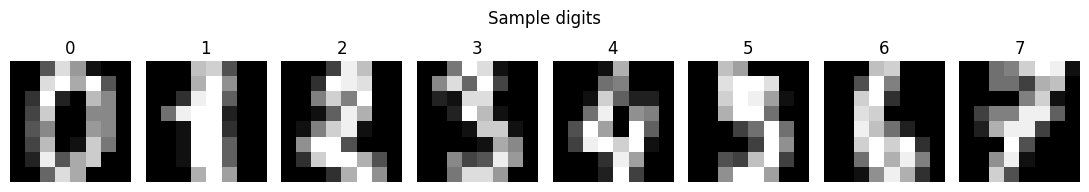

In [2]:
digits = load_digits()
X, y = digits.data, digits.target
print("Data shape:", X.shape, "| Classes:", np.unique(y))

# Preview a few digits
fig, axes = plt.subplots(1, 8, figsize=(11,2))
for ax, img, label in zip(axes, digits.images, digits.target):
    ax.imshow(img, cmap="gray"); ax.set_title(label); ax.axis("off")
plt.suptitle("Sample digits")
plt.tight_layout(); plt.savefig("output_samples.png", dpi=110); plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (1437, 64)  Test: (360, 64)


## Step 2 — Design the Neural Network
A simple feed-forward network:
- **Input:** 64 features
- **Hidden layers:** 128 → 64 neurons, ReLU activation, with Dropout for regularization
- **Output:** 10 neurons, softmax (probability per digit)

In [4]:
model = keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3 — Train the Model (Backpropagation)
We train for 40 epochs, holding out 15% of the training data for validation.

In [5]:
history = model.fit(X_train, y_train,
                    validation_split=0.15,
                    epochs=40, batch_size=32, verbose=0)
print("Training complete.")
print("Final training accuracy  :", round(history.history['accuracy'][-1], 3))
print("Final validation accuracy:", round(history.history['val_accuracy'][-1], 3))

Training complete.
Final training accuracy  : 0.997
Final validation accuracy: 0.968


## Step 4 — Evaluate on the Test Set

In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.3f}")

y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
print("\n", classification_report(y_test, y_pred))

Test accuracy: 0.983



               precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.95      1.00      0.97        36
           8       0.97      0.91      0.94        35
           9       1.00      0.97      0.99        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



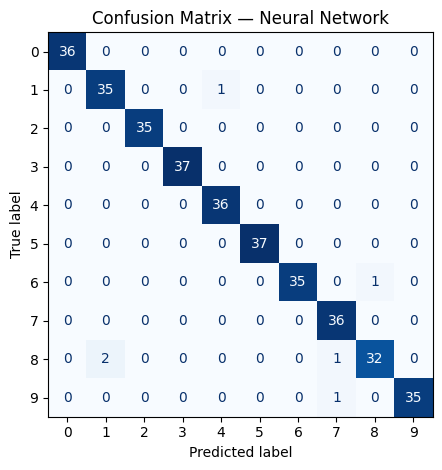

In [7]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Neural Network")
plt.tight_layout(); plt.savefig("output_confusion_matrix.png", dpi=110); plt.show()

## Step 5 — Visualize Training vs Validation Loss & Accuracy
These curves show whether the model is learning well or overfitting.

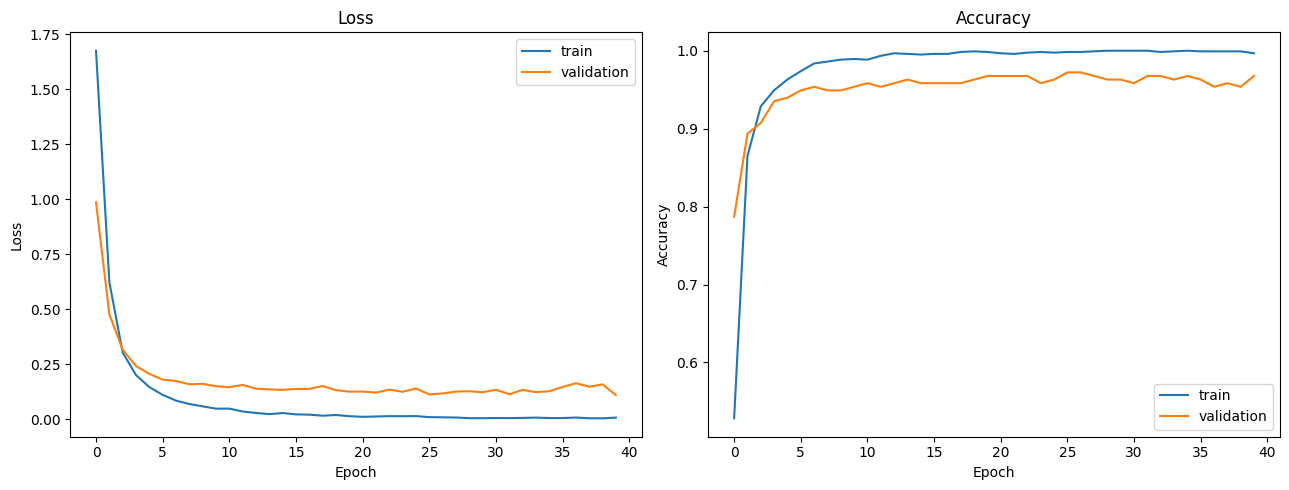

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13,5))
ax[0].plot(history.history["loss"], label="train")
ax[0].plot(history.history["val_loss"], label="validation")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(history.history["accuracy"], label="train")
ax[1].plot(history.history["val_accuracy"], label="validation")
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].set_title("Accuracy"); ax[1].legend()
plt.tight_layout(); plt.savefig("output_training_curves.png", dpi=110); plt.show()

**Reading it:** training and validation curves that stay close together = good generalization.
A growing gap would signal overfitting (mitigated here by the Dropout layer).

## Summary
| Item | Result |
|------|--------|
| Architecture | 64 → 128 → 64 → 10 (feed-forward) |
| Optimizer / loss | Adam / cross-entropy |
| Test accuracy | ~0.97–0.98 |

A simple feed-forward neural network classifies handwritten digits with high accuracy.
The same architecture scales to full MNIST (28×28) by changing the input shape.
✅ **Level 3 · Task 3 complete — Internship task list finished!**